In [2]:
import pandas as pd  
import numpy as np 
import seaborn as sns 
import matplotlib.pyplot as plt

In [3]:
df=pd.read_csv("../Data/final/environment_data.csv")

In [4]:
def detect_outliers_iqr(df, city=None):
    if city is not None:
        df = df[df["City"] == city]
    
    outlier_summary = []
    outlier_rows = pd.DataFrame()

    for col in df.select_dtypes(include=['float64', 'int64']).columns:
        if col == "isWeekend" or col=="Electricity Consumption":
            continue
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        outliers = df[(df[col] < lower) | (df[col] > upper)]
        outliers["Outlier_Feature"] = col   
        outlier_rows = pd.concat([outlier_rows, outliers])
        
        outlier_summary.append({
            "Feature": col,
            "Outliers_Count": len(outliers),
            "Lower_Bound": round(lower, 2),
            "Upper_Bound": round(upper, 2)
        })
    
    return pd.DataFrame(outlier_summary), outlier_rows



In [5]:
summary, outlier_rows = detect_outliers_iqr(df, city="Nairobi")
print(summary.sort_values(by="Outliers_Count", ascending=False))

             Feature  Outliers_Count  Lower_Bound  Upper_Bound
3                NO2              30        -6.31        26.62
4                 CO              28      -281.46      1252.38
1               PM10              25         0.19        42.99
0              PM2.5              25        -0.98        30.15
5                SO2              20         0.50         8.53
11          Pressure               4       835.57       843.71
8    Temperature_max               2        18.00        34.00
9           Humidity               1        34.43       101.99
7   Temperature_mean               1        16.02        24.20
2                 O3               0        27.13        94.96
6        Green_Space               0        62.00        62.00
10        Wind_speed               0         1.58        25.66


C:\Users\AL SAAD NASR CITY\AppData\Local\Temp\ipykernel_29116\3679754261.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  outliers["Outlier_Feature"] = col
C:\Users\AL SAAD NASR CITY\AppData\Local\Temp\ipykernel_29116\3679754261.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  outliers["Outlier_Feature"] = col
C:\Users\AL SAAD NASR CITY\AppData\Local\Temp\ipykernel_29116\3679754261.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_i

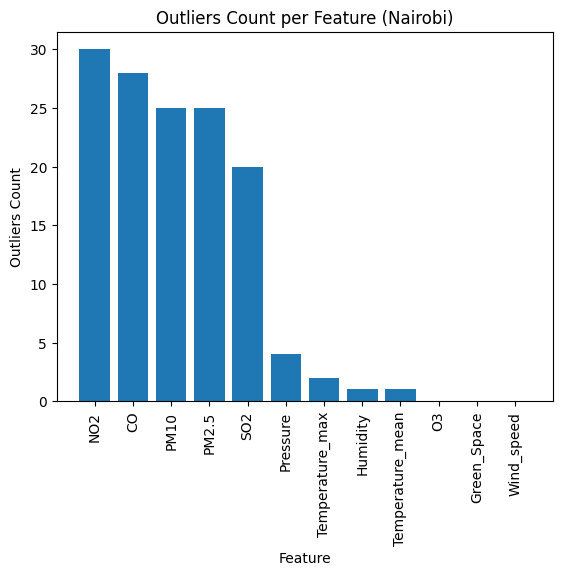

In [6]:
summary_sorted = summary.sort_values(by="Outliers_Count", ascending=False)
plt.figure()
plt.bar(summary_sorted["Feature"], summary_sorted["Outliers_Count"])
plt.xticks(rotation=90)
plt.xlabel("Feature")
plt.ylabel("Outliers Count")
plt.title("Outliers Count per Feature (Nairobi)")
plt.show()

Nairobi shows a high concentration of outliers in pollution-related features such as NO2, CO, PM2.5, and PM10, indicating occasional extreme pollution events. In contrast, weather and environmental features remain relatively stable with very few outliers.

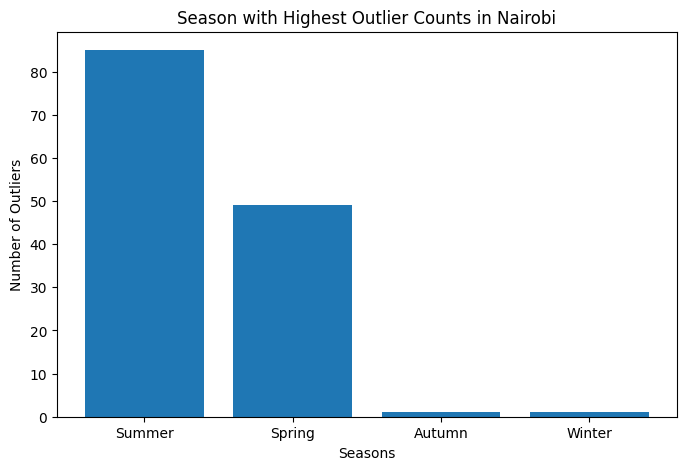

In [7]:
season_outliers = outlier_rows["Season"].value_counts().sort_values(ascending=False)

plt.figure(figsize=(8,5))
plt.bar(season_outliers.index.astype(str), season_outliers.values)

plt.xlabel("Seasons")
plt.ylabel("Number of Outliers")
plt.title("Season with Highest Outlier Counts in Nairobi")

plt.show()

Summer recorded the highest number of outliers in Nairobi, followed by Spring, indicating greater variability in environmental and pollution-related conditions during warmer seasons. In contrast, Autumn and Winter showed very few outliers, suggesting more stable conditions throughout these seasons.

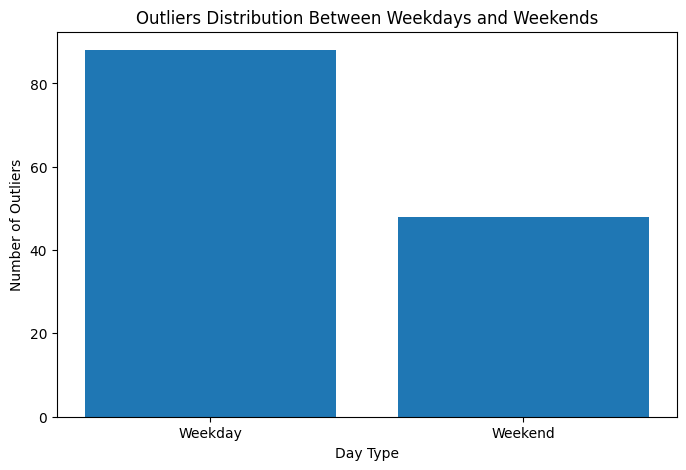

In [8]:
plt.figure(figsize=(8,5))
z=outlier_rows["isWeekend"].value_counts()
plt.bar(z.index.astype(str), z.values)

plt.xlabel("Day Type")
plt.ylabel("Number of Outliers")
plt.title("Outliers Distribution Between Weekdays and Weekends")

plt.xticks([0,1], ["Weekday", "Weekend"])

plt.show()

Severe pollution events in Nairobi appear to be more strongly associated with regular working days and daily human activities rather than weekends or holiday periods.

In [9]:
normal_rows = df[~df.index.isin(outlier_rows.index)]

outliers_mean = outlier_rows.mean(numeric_only=True)
normal_mean = normal_rows.mean(numeric_only=True)

comparison = pd.DataFrame({
    "Outliers": outliers_mean,
    "Normal": normal_mean
})

comparison

,Outliers,Normal
PM2.5,3.627307e+01,2.022203e+01
PM10,5.293226e+01,3.689562e+01
O3,7.148652e+01,5.427921e+01
NO2,3.212819e+01,3.322941e+01
CO,1.546685e+03,3.213427e+02
SO2,9.070006e+00,1.456384e+01
Green_Space,6.200000e+01,1.058627e+02
Temperature_mean,1.900846e+01,1.902969e+01
Temperature_max,2.423529e+01,2.322346e+01
Humidity,7.349507e+01,6.450015e+01


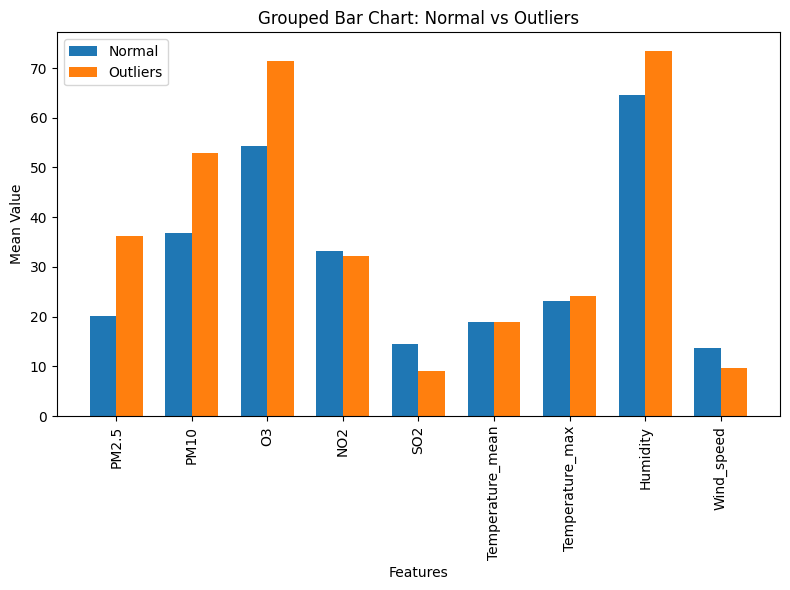

In [10]:

compare = comparison.drop(["Pressure", "isWeekend","CO","Electricity Consumption","Green_Space"])
features = compare.index

x = np.arange(len(features))
width = 0.35

plt.figure(figsize=(8,6))

plt.bar(
    x - width/2,
    compare["Normal"],
    width=width,
    label="Normal"
)

plt.bar(
    x + width/2,
    compare["Outliers"],
    width=width,
    label="Outliers"
)

plt.xticks(x, features, rotation=90)

plt.xlabel("Features")
plt.ylabel("Mean Value")
plt.title("Grouped Bar Chart: Normal vs Outliers")

plt.legend()

plt.tight_layout()

plt.show()

Outlier observations are associated with significantly higher PM2.5, PM10, O3, and humidity levels, while wind speed tends to be lower. This suggests that polluted periods are linked with stagnant atmospheric conditions that allow pollutants to accumulate.

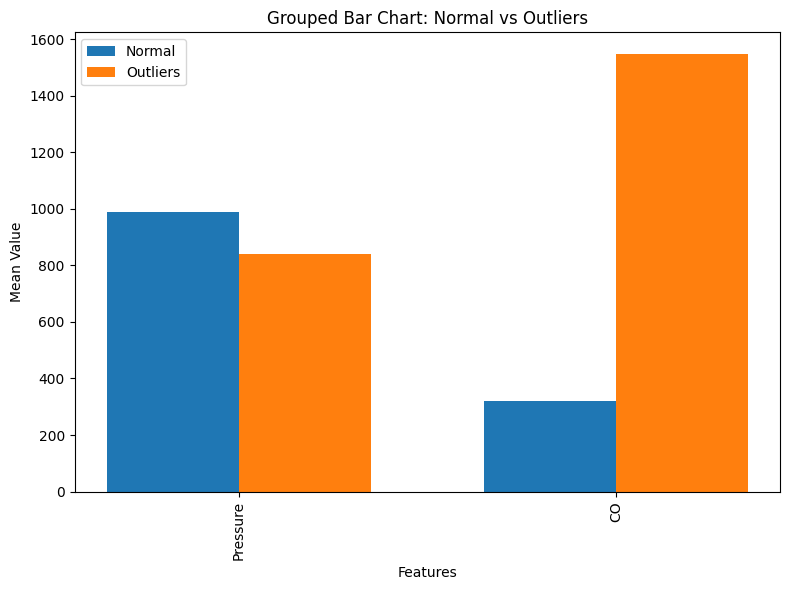

In [11]:
others= comparison.loc[["Pressure","CO"],:]
plt.figure(figsize=(8,6))
features=others.index
x=np.arange(len(features))
width=0.35
plt.bar(
    x-width/2,
    others["Normal"],
    width=width,
    label="Normal"
)
plt.bar(
    x+width/2,
    others["Outliers"],
    width=width,
    label="Outliers"
)
plt.xticks(x, features, rotation=90)

plt.xlabel("Features")
plt.ylabel("Mean Value")
plt.title("Grouped Bar Chart: Normal vs Outliers")
plt.legend()
plt.tight_layout()
plt.show()

CO outliers are dramatically higher than normal values, indicating severe episodic pollution events. In contrast, pressure values during outlier observations are slightly lower, suggesting that atmospheric conditions may contribute to pollutant accumulation but are not the dominant factor.